In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36085,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41979,Total threads: 4
Dashboard: http://127.0.0.1:34331/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:41805,


In [3]:
path_atm = "/nird/projects/NS1004K/elihho/NHIST_tropstratchem_20251110_pinatubo2iceland/atm/hist"
ds = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20251110_moved2iceland.cam.h0.*.nc", combine="by_coords", parallel=True)

In [22]:
path_atm_pin = "/projects/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_pin = xr.open_mfdataset(f"{path_atm_pin}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

In [4]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds['time'].values])
ds= ds.assign_coords(time=shifted_time)

print(ds["time"].values[:5])

[cftime.DatetimeNoLeap(1990, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1990, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1990, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1990, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1990, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


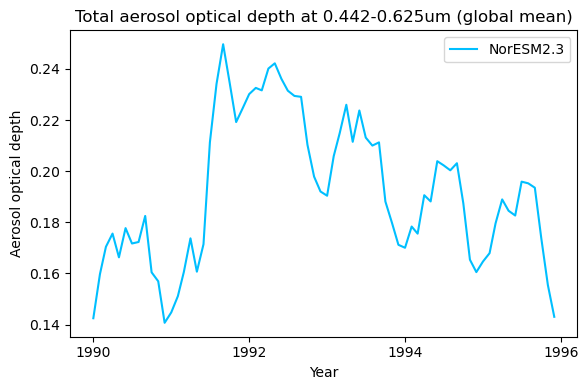

In [5]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
daylight = "DAYFOC"  # Fraction of day in the month

ts_aod = ds[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = ds[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
#ts_aod = ts_aod.resample(time="1YE").mean()

plt.figure(figsize=(6, 4))
ts_aod.plot(color = "deepskyblue", label = "NorESM2.3")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global mean)")
plt.legend()
plt.tight_layout()
plt.show()

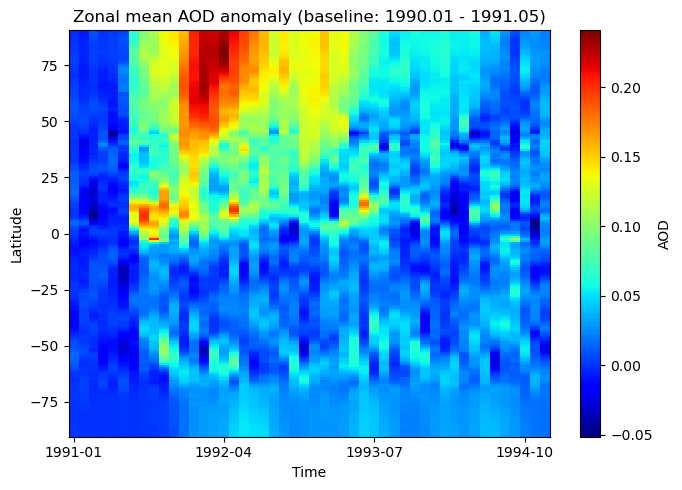

In [6]:
aod = ds[aod500]
daylight_monthly_nw = ds[daylight]
aod = aod / daylight_monthly_nw

pre_eruption = aod.sel(time=slice('1990-01-01', '1991-05-01'))
base = pre_eruption.groupby("time.month").mean()
aod_anom = aod.groupby("time.month") - base

aod_zoom = aod_anom.sel(time=slice('1991-01-01', '1994-12-01'))
time_zoom = aod_zoom['time'].values
aod_lat_time = aod_zoom.mean(dim="lon")
lat = aod_lat_time["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom,
    lat,
    aod_lat_time.T, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="AOD")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean AOD anomaly (baseline: 1990.01 - 1991.05)")
plt.tight_layout()
plt.show()

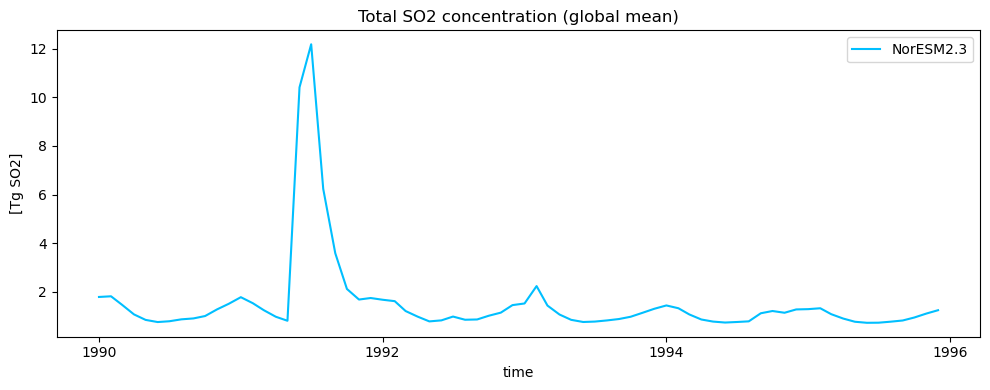

In [7]:
M_SO2 = 64.066     
M_air = 28.9647   
m_air_global = 5.3 * 10**21 
K_so2 = (M_SO2 / M_air) * m_air_global *10**(-12)    # mol/mol → Tg conversion factor

lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])

so2_tg = so2 * K_so2

plt.figure(figsize=(10, 4))
so2_tg.plot(color="deepskyblue", label="NorESM2.3")
plt.ylabel("[Tg SO2]")
plt.title("Total SO2 concentration (global mean)")
plt.legend()
plt.tight_layout()
plt.show()

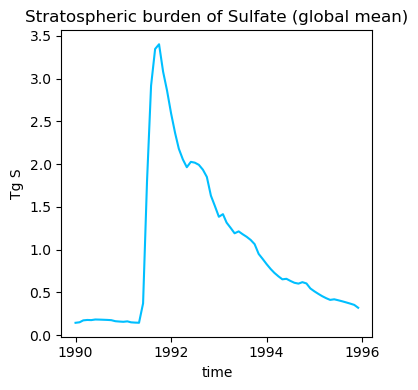

In [8]:
Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
tropopause = ds["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
p_lev = tropopause * 0.01
M_strat_air = 0.099 * Matmos   #9.9% of the total mass of the atmosphere
Mo = 15.999
Mso4 = Ms + (4 * Mo)
c = Ms/Mso4

mmr_sulf = ds["mmr_SULFATE"]
so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev)
so4_burd = so4_burd.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden = so4_burd * M_strat_air *10**(-12)
so4_burden_TgS = so4_burden * c

plt.figure(figsize=(4, 4))
so4_burden_TgS.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
plt.title("Stratospheric burden of Sulfate (global mean)")
plt.tight_layout()

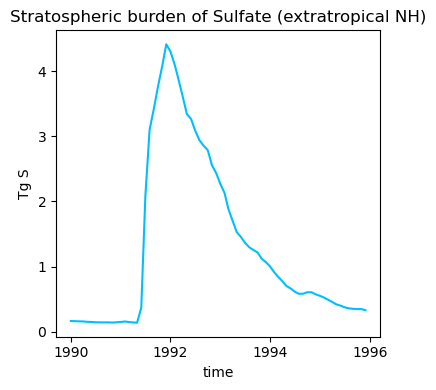

In [9]:
M_strat_air = 0.099 * Matmos   #9.9% of the total mass of the atmosphere
Mo = 15.999
Mso4 = Ms + (4 * Mo)
c = Ms/Mso4

mmr_sulf = ds["mmr_SULFATE"]
so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev)
so4_burd_NH = so4_burd.sel(lat=slice(20, 90))
so4_burd = so4_burd_NH.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden = so4_burd * M_strat_air *10**(-12)
so4_burden_TgS = so4_burden * c

plt.figure(figsize=(4, 4))
so4_burden_TgS.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
plt.title("Stratospheric burden of Sulfate (extratropical NH)")
plt.tight_layout()

In [10]:
lat_pin = ds_pin["lat"]
weighted_lat_pin = np.cos(np.deg2rad(lat_pin))
tropopause = ds_pin["TROP_P"].weighted(weighted_lat_pin).mean(dim=["lat", "lon"])
p_lev = tropopause * 0.01

M_strat_air = 0.099 * Matmos
Mo = 15.999
Mso4 = Ms + 4 * Mo
c = Ms / Mso4

mmr_sulf_pin = ds_pin["mmr_SULFATE"]

so4_burd_pin = mmr_sulf_pin.where(mmr_sulf_pin["lev"] <= p_lev)
so4_burd_pin = so4_burd_pin.weighted(weighted_lat_pin).mean(dim=["lat", "lon", "lev"])
so4_burden_pin = so4_burd_pin * M_strat_air * 1e-12
so4_burden_TgS_pin = so4_burden_pin * c
so4_burden_TgS_pin_yr = so4_burden_TgS_pin.sel(time=slice("1991-01-01", "1995-12-31"))

plt.figure(figsize=(10,4))
so4_burden_TgS_pin_yr.plot(color="deepskyblue", label="NorESM2.3")
plt.ylabel("Tg S")

years = np.arange(1991, 1996)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks)

plt.title("Stratospheric burden of Sulfate (global mean)")


NameError: name 'ds_pin' is not defined

Text(0.5, 1.0, 'Stratospheric burden of Sulfate (Tropics)')

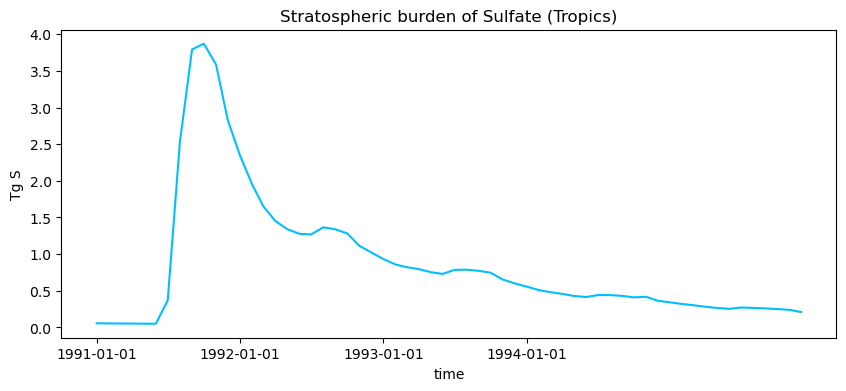

In [ ]:
a_glob = 510000000
h_trop = 4440
d = 12756

a_trop = np.pi * d * h_trop
ratio = a_trop/a_glob

so4_trop = mmr_sulf_pin.sel(lat=slice(-20, 20))
so4_burd_trop = so4_trop.where(so4_trop["lev"] <= p_lev)
so4_burd_trop = so4_burd_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden_trop = so4_burd_trop * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop = so4_burden_trop * c
so4_burden_TgS_trop_Pin = so4_burden_TgS_trop.sel(time=[t for t in so4_burden_TgS_trop.time.values if 1991 <= t.year <= 1995])

plt.figure(figsize=(10, 4))
so4_burden_TgS_trop_Pin.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
years = np.arange(1991, 1995)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks)
plt.title("Stratospheric burden of Sulfate (Tropics)")

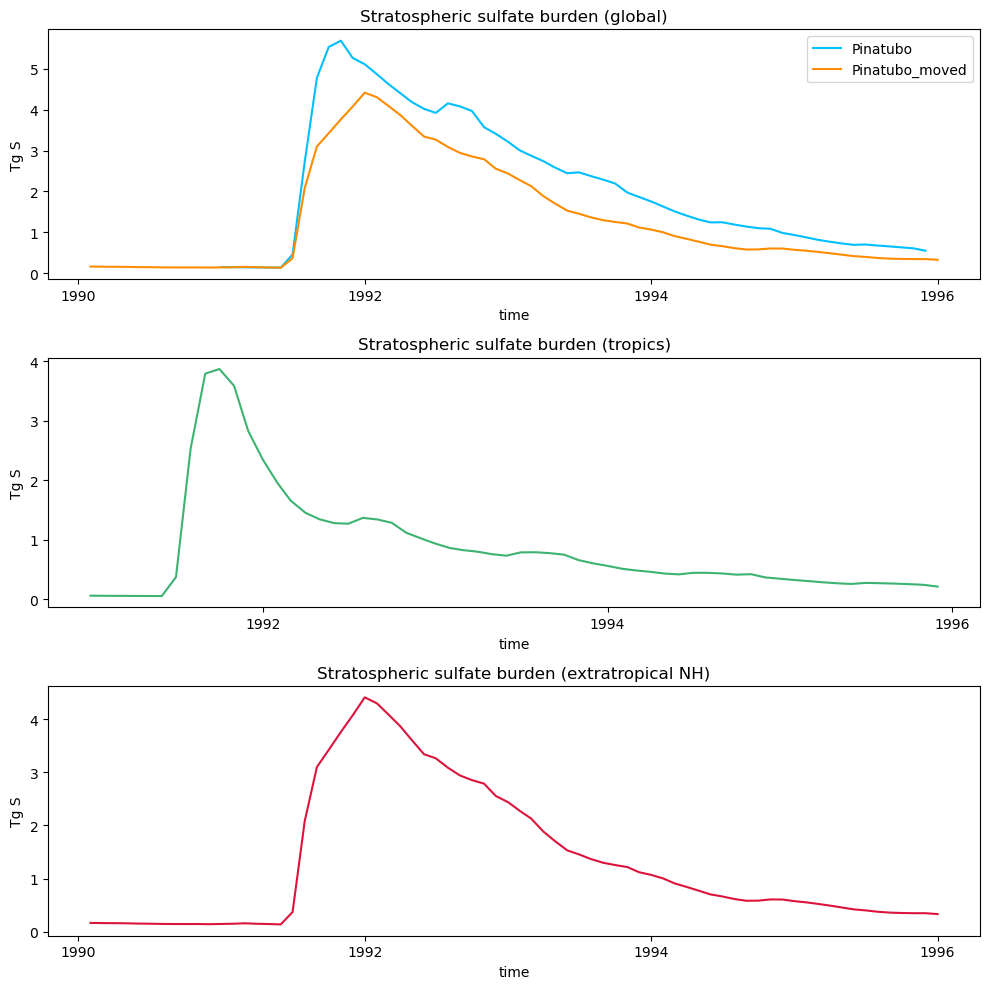

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

ax = axes[0]
so4_burden_TgS_pin_yr.plot(ax=ax, color="deepskyblue", label="Pinatubo")
so4_burden_TgS.plot(ax=ax, color="darkorange", label="Pinatubo_moved")
ax.set_title("Stratospheric sulfate burden (global)")
ax.set_ylabel("Tg S")
ax.legend()

ax = axes[1]
so4_burden_TgS_trop_Pin.plot(ax=ax, color="mediumseagreen")
ax.set_title("Stratospheric sulfate burden (tropics)")
ax.set_ylabel("Tg S")

ax = axes[2]
so4_burden_TgS.plot(ax=ax, color="crimson")
ax.set_title("Stratospheric sulfate burden (extratropical NH)")
ax.set_ylabel("Tg S")

plt.tight_layout()
plt.show()


In [11]:
ds["REFF_AERO"]

<xarray.DataArray 'REFF_AERO' (time: 72, lev: 32, lat: 192, lon: 288)> Size: 510MB
dask.array<concatenate, shape=(72, 32, 192, 288), dtype=float32, chunksize=(1, 32, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 576B 1990-01-01 00:00:00 ... 1995-12-01 00:00:00
Attributes:
    mdims:      1
    units:      cm
    long_name:  aerosol effective radius

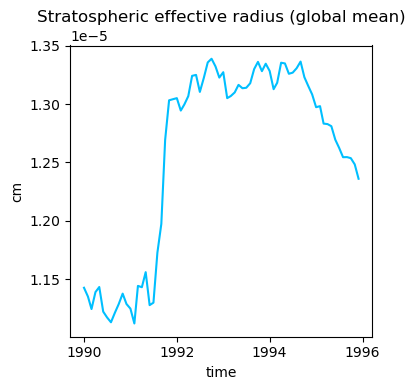

In [14]:
tropopause = ds["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
p_lev = tropopause * 0.01
SReff = ds["REFF_AERO"].where(ds["REFF_AERO"]["lev"] <= p_lev)
SReff = SReff.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])

plt.figure(figsize=(4, 4))
SReff.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("cm")
plt.title("Stratospheric effective radius (global mean)")
plt.tight_layout()

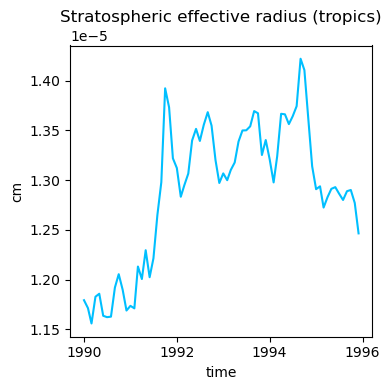

In [15]:
SReff = ds["REFF_AERO"].where(ds["REFF_AERO"]["lev"] <= p_lev)
SReff_trop = SReff.sel(lat = slice(-20,20))
SReff_trop = SReff_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])

plt.figure(figsize=(4, 4))
SReff_trop.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("cm")
plt.title("Stratospheric effective radius (tropics)")
plt.tight_layout()

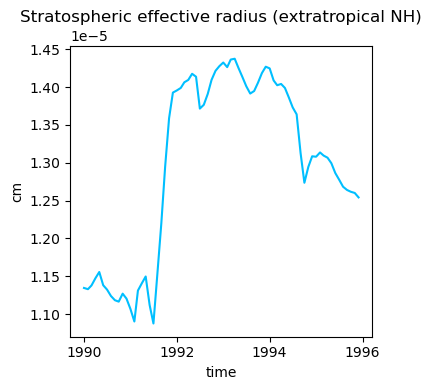

In [17]:
SReff = ds["REFF_AERO"].where(ds["REFF_AERO"]["lev"] <= p_lev)
SReff_nh = SReff.sel(lat = slice(20,90))
SReff_nh = SReff_nh.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])

plt.figure(figsize=(4, 4))
SReff_nh.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("cm")
plt.title("Stratospheric effective radius (extratropical NH)")
plt.tight_layout()